In [659]:
import utils
import numpy as np
import pandas as pd
import os
from scipy.stats import chisquare

import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme
sns.set_theme()

pd.set_option('future.no_silent_downcasting', True)
#pd.set_option('display.max_rows', None)

In [660]:
# Make output folder
output_dir = os.path.join('..','plots','behavioural_pilot','behavioural_modelling')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [661]:
# Preparation
experiment_output_path = os.path.join('..', '..', 'phd_1_task', 'experiment_output', 'behavioural_files')

In [662]:
unique_subject_ids = [999]
unique_sessions = [23]

recent_results = utils.analysis_functions.list_files_with_date_and_subject_id(experiment_output_path, unique_subject_ids, unique_sessions)
print(recent_results)

['../../phd_1_task/experiment_output/behavioural_files/experiment_output_sub-999_session-23_computer_and_keyboard_2024-06-12_18-02-24.csv']


In [663]:
# Opens all the files and combines them into one dataframe
combined_results_dataframe = utils.analysis_functions.combine_result_files(recent_results)
print(combined_results_dataframe)

     trial  emotional_cue_time response objectively_correct  \
0        0        1.718208e+09     down                Even   
1        1        1.718208e+09     down                Even   
2        2        1.718208e+09     down                Even   
3        3        1.718208e+09       up                Even   
4        4        1.718208e+09       up                Even   
..     ...                 ...      ...                 ...   
675    675        1.718212e+09     down                True   
676    676        1.718212e+09     down                True   
677    677        1.718212e+09     down               False   
678    678        1.718212e+09     down               False   
679    679        1.718212e+09     down                True   

    subjectively_correct  response_time   RT_s  stimuli_type  iti  \
0                   True   1.718208e+09  0.965             3    2   
1                   True   1.718208e+09  0.455             1    2   
2                  False   1.718208e

# WSLS
Determine how often the Win-Stay Lost-Shift strategy is used. Plot whether there is a difference between conditions.

In [664]:
# Add congruency as a column
combined_results_dataframe['congruency'] = combined_results_dataframe.apply(utils.analysis_functions.check_congruency, axis=1)

In [665]:
# Add two 'one-back' columns and a WSLS column
dataframe_WSLS = utils.learning_models.add_WSLS_column(combined_results_dataframe)
print(dataframe_WSLS)

     trial  emotional_cue_time response objectively_correct  \
0        1        1.718208e+09     down                Even   
1        2        1.718208e+09     down                Even   
2        5        1.718208e+09       up                Even   
3        7        1.718208e+09       up                Even   
4        8        1.718208e+09     down                True   
..     ...                 ...      ...                 ...   
675    671        1.718212e+09     down               False   
676    673        1.718212e+09       up                True   
677    674        1.718212e+09     down               False   
678    677        1.718212e+09     down               False   
679    678        1.718212e+09     down               False   

    subjectively_correct  response_time   RT_s  stimuli_type  iti  \
0                   True   1.718208e+09  0.455             1    2   
1                  False   1.718208e+09  0.381             1    2   
2                   True   1.718208e

# Check congruency, valence and volatility

In [666]:
# Check a block's congruency
dataframe_WSLS['congruency'] = dataframe_WSLS.apply(utils.analysis_functions.check_congruency, axis=1)

# Check a block's valence
dataframe_WSLS['valence'] = dataframe_WSLS.apply(utils.analysis_functions.check_valence, axis=1)

# Check a block's volatility
dataframe_WSLS = dataframe_WSLS[dataframe_WSLS['probability_condition'] != 50]
dataframe_with_volatility = dataframe_WSLS.groupby('stimuli_type', group_keys=False).apply(utils.analysis_functions.check_volatility)
dataframe_with_volatility = dataframe_with_volatility.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])
dataframe_with_volatility.reset_index(drop=True, inplace=True)
print(dataframe_with_volatility[['subject_id', 'session', 'congruency', 'valence', 'volatility']])

dataframe_without_volatility = dataframe_WSLS

    subject_id     session   congruency valence volatility
0      sub-999  session-23  incongruent   angry     stable
1      sub-999  session-23  incongruent   angry     stable
2      sub-999  session-23  incongruent   angry     stable
3      sub-999  session-23  incongruent   angry     stable
4      sub-999  session-23  incongruent   angry     stable
..         ...         ...          ...     ...        ...
611    sub-999  session-23    congruent   happy   volatile
612    sub-999  session-23    congruent   happy   volatile
613    sub-999  session-23    congruent   happy   volatile
614    sub-999  session-23    congruent   happy   volatile
615    sub-999  session-23    congruent   happy   volatile

[616 rows x 5 columns]


/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_4726/2745853200.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dataframe_with_volatility = dataframe_WSLS.groupby('stimuli_type', group_keys=False).apply(utils.analysis_functions.check_volatility)


# Plot the WSLS separately for staying and shifting
- Valence
- Volatility
- Congruency
- Valence/Volatility
- Congruency/Volatility

In [667]:
# First combine two columns
grouping_factor = 'valence'
dataframe_valence_volatility = dataframe_with_volatility

# Average the WSLS values for the staying condition
WSLS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS == 3) | (dataframe_valence_volatility.WSLS == 4)].index, inplace=False)
WSLS_dataframe_win_p['WSLS'] = WSLS_dataframe_win_p['WSLS'] - 1
WSLS_win_p_averages = WSLS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then do the same for the shifting condition
WSLS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS == 1) | (dataframe_valence_volatility.WSLS == 2)].index, inplace=False)
WSLS_dataframe_lose_p['WSLS'] = WSLS_dataframe_lose_p['WSLS'] - 3
WSLS_lose_p_averages = WSLS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then combine the two and rename the WSLS columns
WSLS_dataframe_averages = WSLS_win_p_averages[['subject_id', 'session', grouping_factor]]
WSLS_dataframe_averages['p_win_stay'] = WSLS_win_p_averages['WSLS']
WSLS_dataframe_averages['p_lose_stay'] = WSLS_lose_p_averages['WSLS']
print(WSLS_dataframe_averages)

  subject_id     session valence  p_win_stay  p_lose_stay
0    sub-999  session-23   angry    0.625767     0.406667
1    sub-999  session-23   happy    0.640244     0.320000


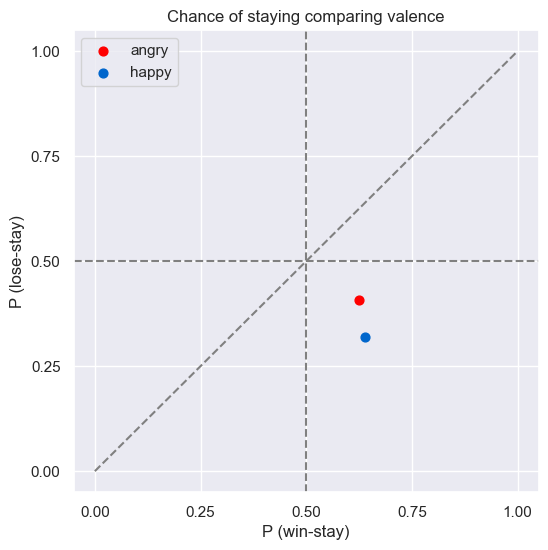

In [668]:
# Plot everything in a scatterplot
plt.figure(figsize=(6, 6))
scatterplot_colours = ['#FF0000', '#0066CC']

# Plot points with different colors for congruency, valence, and volatility
for i, row in WSLS_dataframe_averages.iterrows():
    plt.scatter(row['p_win_stay'], row['p_lose_stay'],
                color=scatterplot_colours[i],
                alpha=1,
                s=40,  # Size of the points
                label=f"{row[grouping_factor]}")

# Plotting extra lines
plt.axhline(0.5, color='grey', linestyle='dashed')
plt.axvline(0.5, color='grey', linestyle='dashed')
plt.plot([0, 1], [0, 1], color='grey', linestyle='dashed')

# Adding labels and title
plt.xlabel('P (win-stay)')
plt.xticks([0, 0.25, 0.5, 0.75, 1])
plt.ylabel('P (lose-stay)')
plt.yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying comparing {grouping_factor}'
plt.title(plot_name)
plt.legend()

plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

In [669]:
# First combine two columns
grouping_factor = 'volatility'
dataframe_valence_volatility = dataframe_with_volatility

# Average the WSLS values for the staying condition
WSLS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS == 3) | (dataframe_valence_volatility.WSLS == 4)].index, inplace=False)
WSLS_dataframe_win_p['WSLS'] = WSLS_dataframe_win_p['WSLS'] - 1
WSLS_win_p_averages = WSLS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then do the same for the shifting condition
WSLS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS == 1) | (dataframe_valence_volatility.WSLS == 2)].index, inplace=False)
WSLS_dataframe_lose_p['WSLS'] = WSLS_dataframe_lose_p['WSLS'] - 3
WSLS_lose_p_averages = WSLS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then combine the two and rename the WSLS columns
WSLS_dataframe_averages = WSLS_win_p_averages[['subject_id', 'session', grouping_factor]]
WSLS_dataframe_averages['p_win_stay'] = WSLS_win_p_averages['WSLS']
WSLS_dataframe_averages['p_lose_stay'] = WSLS_lose_p_averages['WSLS']
print(WSLS_dataframe_averages)

  subject_id     session volatility  p_win_stay  p_lose_stay
0    sub-999  session-23     stable    0.611940     0.317073
1    sub-999  session-23   volatile    0.647668     0.395480


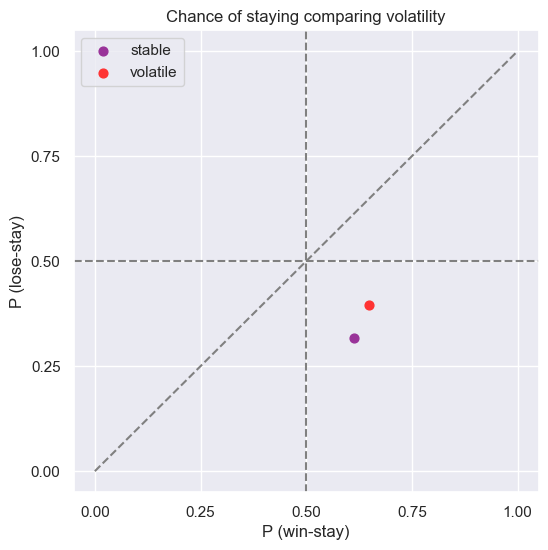

In [670]:
# Plot everything in a scatterplot
plt.figure(figsize=(6, 6))
scatterplot_colours = ['#993399', '#FF3333']

# Plot points with different colors for congruency, valence, and volatility
for i, row in WSLS_dataframe_averages.iterrows():
    plt.scatter(row['p_win_stay'], row['p_lose_stay'],
                color=scatterplot_colours[i],
                alpha=1,
                s=40,  # Size of the points
                label=f"{row[grouping_factor]}")

# Plotting extra lines
plt.axhline(0.5, color='grey', linestyle='dashed')
plt.axvline(0.5, color='grey', linestyle='dashed')
plt.plot([0, 1], [0, 1], color='grey', linestyle='dashed')

# Adding labels and title
plt.xlabel('P (win-stay)')
plt.xticks([0, 0.25, 0.5, 0.75, 1])
plt.ylabel('P (lose-stay)')
plt.yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying comparing {grouping_factor}'
plt.title(plot_name)
plt.legend()

plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

In [671]:
# First combine two columns
grouping_factor = 'congruency'
dataframe_valence_volatility = dataframe_with_volatility

# Average the WSLS values for the staying condition
WSLS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS == 3) | (dataframe_valence_volatility.WSLS == 4)].index, inplace=False)
WSLS_dataframe_win_p['WSLS'] = WSLS_dataframe_win_p['WSLS'] - 1
WSLS_win_p_averages = WSLS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then do the same for the shifting condition
WSLS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS == 1) | (dataframe_valence_volatility.WSLS == 2)].index, inplace=False)
WSLS_dataframe_lose_p['WSLS'] = WSLS_dataframe_lose_p['WSLS'] - 3
WSLS_lose_p_averages = WSLS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then combine the two and rename the WSLS columns
WSLS_dataframe_averages = WSLS_win_p_averages[['subject_id', 'session', grouping_factor]]
WSLS_dataframe_averages['p_win_stay'] = WSLS_win_p_averages['WSLS']
WSLS_dataframe_averages['p_lose_stay'] = WSLS_lose_p_averages['WSLS']
print(WSLS_dataframe_averages)

  subject_id     session   congruency  p_win_stay  p_lose_stay
0    sub-999  session-23    congruent    0.598639     0.329193
1    sub-999  session-23  incongruent    0.661111     0.402878


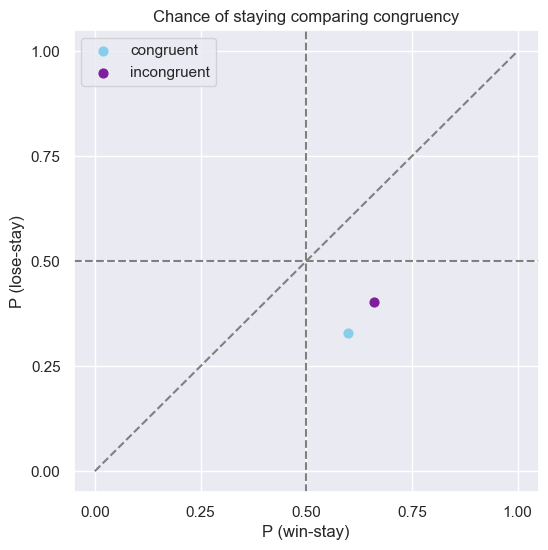

In [672]:
# Plot everything in a scatterplot
plt.figure(figsize=(6, 6))
scatterplot_colours = ['#87CEEB', '#7E1E9C']

# Plot points with different colors for congruency, valence, and volatility
for i, row in WSLS_dataframe_averages.iterrows():
    plt.scatter(row['p_win_stay'], row['p_lose_stay'],
                color=scatterplot_colours[i],
                alpha=1,
                s=40,  # Size of the points
                label=f"{row[grouping_factor]}")

# Plotting extra lines
plt.axhline(0.5, color='grey', linestyle='dashed')
plt.axvline(0.5, color='grey', linestyle='dashed')
plt.plot([0, 1], [0, 1], color='grey', linestyle='dashed')

# Adding labels and title
plt.xlabel('P (win-stay)')
plt.xticks([0, 0.25, 0.5, 0.75, 1])
plt.ylabel('P (lose-stay)')
plt.yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying comparing {grouping_factor}'
plt.title(plot_name)
plt.legend()

plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

In [673]:
# First combine two columns
grouping_factor_1 = 'valence'
grouping_factor_2 = 'volatility'
grouping_factor = f'{grouping_factor_1}_{grouping_factor_2}'
dataframe_valence_volatility = dataframe_with_volatility
dataframe_valence_volatility[grouping_factor] = dataframe_valence_volatility[grouping_factor_1] + ' & ' + dataframe_valence_volatility[grouping_factor_2]

# Average the WSLS values for the staying condition
WSLS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS == 3) | (dataframe_valence_volatility.WSLS == 4)].index, inplace=False)
WSLS_dataframe_win_p['WSLS'] = WSLS_dataframe_win_p['WSLS'] - 1
WSLS_win_p_averages = WSLS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then do the same for the shifting condition
WSLS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS == 1) | (dataframe_valence_volatility.WSLS == 2)].index, inplace=False)
WSLS_dataframe_lose_p['WSLS'] = WSLS_dataframe_lose_p['WSLS'] - 3
WSLS_lose_p_averages = WSLS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then combine the two and rename the WSLS columns
WSLS_dataframe_averages = WSLS_win_p_averages[['subject_id', 'session', grouping_factor]]
WSLS_dataframe_averages['p_win_stay'] = WSLS_win_p_averages['WSLS']
WSLS_dataframe_averages['p_lose_stay'] = WSLS_lose_p_averages['WSLS']
print(WSLS_dataframe_averages)

  subject_id     session valence_volatility  p_win_stay  p_lose_stay
0    sub-999  session-23     angry & stable    0.650794     0.384615
1    sub-999  session-23   angry & volatile    0.610000     0.423529
2    sub-999  session-23     happy & stable    0.577465     0.241379
3    sub-999  session-23   happy & volatile    0.688172     0.369565


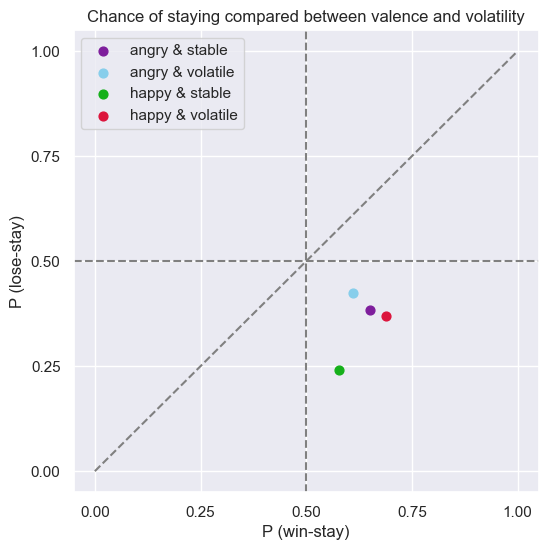

In [674]:
# Plot everything in a scatterplot
plt.figure(figsize=(6, 6))
scatterplot_colours = ['#7E1E9C', '#87CEEB', '#15B01A', '#DC143C']

# Plot points with different colors for congruency, valence, and volatility
for i, row in WSLS_dataframe_averages.iterrows():
    plt.scatter(row['p_win_stay'], row['p_lose_stay'],
                color=scatterplot_colours[i],
                alpha=1,
                s=40,  # Size of the points
                label=f"{row[grouping_factor]}")

# Plotting extra lines
plt.axhline(0.5, color='grey', linestyle='dashed')
plt.axvline(0.5, color='grey', linestyle='dashed')
plt.plot([0, 1], [0, 1], color='grey', linestyle='dashed')

# Adding labels and title
plt.xlabel('P (win-stay)')
plt.xticks([0, 0.25, 0.5, 0.75, 1])
plt.ylabel('P (lose-stay)')
plt.yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying compared between {grouping_factor_1} and {grouping_factor_2}'
plt.title(plot_name)
plt.legend()

plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

In [675]:
# First combine two columns
grouping_factor_1 = 'congruency'
grouping_factor_2 = 'volatility'
grouping_factor = f'{grouping_factor_1}_{grouping_factor_2}'
dataframe_valence_volatility = dataframe_with_volatility
dataframe_valence_volatility[grouping_factor] = dataframe_valence_volatility[grouping_factor_1] + ' & ' + dataframe_valence_volatility[grouping_factor_2]

# Average the WSLS values for the staying condition
WSLS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS == 3) | (dataframe_valence_volatility.WSLS == 4)].index, inplace=False)
WSLS_dataframe_win_p['WSLS'] = WSLS_dataframe_win_p['WSLS'] - 1
WSLS_win_p_averages = WSLS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then do the same for the shifting condition
WSLS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS == 1) | (dataframe_valence_volatility.WSLS == 2)].index, inplace=False)
WSLS_dataframe_lose_p['WSLS'] = WSLS_dataframe_lose_p['WSLS'] - 3
WSLS_lose_p_averages = WSLS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then combine the two and rename the WSLS columns
WSLS_dataframe_averages = WSLS_win_p_averages[['subject_id', 'session', grouping_factor]]
WSLS_dataframe_averages['p_win_stay'] = WSLS_win_p_averages['WSLS']
WSLS_dataframe_averages['p_lose_stay'] = WSLS_lose_p_averages['WSLS']
print(WSLS_dataframe_averages)

  subject_id     session   congruency_volatility  p_win_stay  p_lose_stay
0    sub-999  session-23      congruent & stable    0.529412     0.155556
1    sub-999  session-23    congruent & volatile    0.619469     0.396552
2    sub-999  session-23    incongruent & stable    0.640000     0.410256
3    sub-999  session-23  incongruent & volatile    0.687500     0.393443


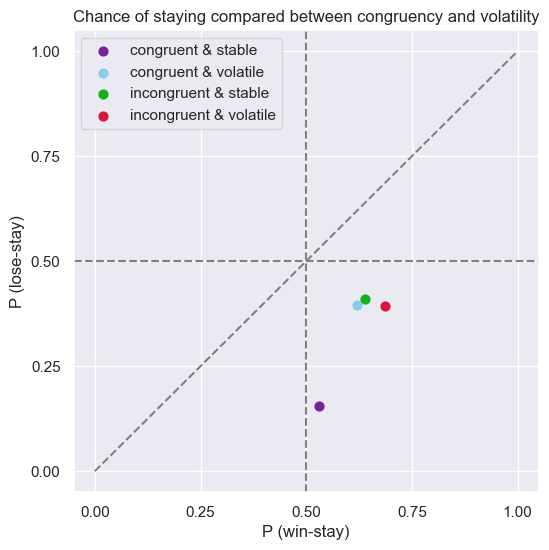

In [676]:
# Plot everything in a scatterplot
plt.figure(figsize=(6, 6))
scatterplot_colours = ['#7E1E9C', '#87CEEB', '#15B01A', '#DC143C']

# Plot points with different colors for congruency, valence, and volatility
for i, row in WSLS_dataframe_averages.iterrows():
    plt.scatter(row['p_win_stay'], row['p_lose_stay'],
                color=scatterplot_colours[i],
                alpha=1,
                s=40,  # Size of the points
                label=f"{row[grouping_factor]}")

# Plotting extra lines
plt.axhline(0.5, color='grey', linestyle='dashed')
plt.axvline(0.5, color='grey', linestyle='dashed')
plt.plot([0, 1], [0, 1], color='grey', linestyle='dashed')

# Adding labels and title
plt.xlabel('P (win-stay)')
plt.xticks([0, 0.25, 0.5, 0.75, 1])
plt.ylabel('P (lose-stay)')
plt.yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying compared between {grouping_factor_1} and {grouping_factor_2}'
plt.title(plot_name)
plt.legend()

plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()